# Qwen3.5 → Harmony QA Dataset for LoRA Fine-Tuning

### Journal Club 2026 — Section 5: Fine-tuning — Training LLMs for Medical Knowledge

This notebook uses [`Qwen/Qwen3.5-4B`](https://huggingface.co/Qwen/Qwen3.5-4B) to
**synthesise an image-grounded visual question-answering dataset** from the Indiana
University (Open-i) chest X-ray collection, and writes it in the
[**OpenAI Harmony**](https://cookbook.openai.com/articles/openai-harmony) response
format so it can be consumed directly by a LoRA fine-tuning run.

It is the data-generation half of Section 5. Training code lives in a separate notebook;
this one stops once a validated `train.jsonl` / `val.jsonl` pair exists on disk.

**Pipeline**

| Stage | What happens | Why |
|---|---|---|
| 1 | Qwen3.5 sees image **+ radiologist report** and proposes questions | The report constrains questions to things actually answerable |
| 2 | Qwen3.5 answers each question from the **image alone**, thinking enabled | Produces an honest reasoning trace, not a paraphrase of the report |
| 3 | Each answer is checked against the report | Ungrounded answers are flagged and filtered, not silently kept |
| 4 | Surviving samples are rendered as Harmony conversations | `analysis` = captured reasoning, `final` = answer |

The deliberate separation in stages 1–2 is the point. If the model could see the report
while answering, every answer would be grounded by construction and the dataset would
teach the student model nothing about looking at images. By hiding the report at answer
time and using it only as a *referee*, the filter in stage 3 measures something real.

> **Research and teaching only.** Qwen3.5 is not a clinically validated radiology model.
> A synthetic dataset built from it inherits every one of its failure modes. Do not use
> the resulting data, or any model trained on it, for patient care.

> **Prerequisite.** This notebook assumes you have already run
> `qwen35_chest_xray_report_generation.ipynb` from Section 4. The environment setup,
> Kaggle download, and model-loading cells are carried over from it deliberately, so the
> two notebooks stay directly comparable.

---
## 1. Install dependencies

`bitsandbytes` is listed but **optional** — it only enables 4-bit loading. The model
loads fine without it, in bf16/fp16, which is what the fine-tuning notebook does. If its
install fails, keep going.

In [1]:
# Run this line once if PIL is broken, then comment it out again.
# !pip install --force-reinstall --no-cache-dir pillow

In [2]:
RUN_INSTALLS = False

# Qwen3.5 uses a Gated DeltaNet + sparse-MoE architecture that older transformers
# releases do not recognize. If loading fails with "unrecognized model type
# qwen3_5", set TRANSFORMERS_FROM_GIT = True and re-run.
#
# pillow / pandas / matplotlib are deliberately NOT upgraded: Colab ships working
# copies, and `pip install -U pillow` over the preinstalled version can leave a
# mixed-version tree that fails with "cannot import name '_Ink' from 'PIL._typing'".
TRANSFORMERS_FROM_GIT = False

# bitsandbytes is installed separately and allowed to fail. It buys 4-bit
# loading and nothing else; the model runs unquantized without it.
INSTALL_BITSANDBYTES = True

if RUN_INSTALLS:
    import subprocess
    import sys

    transformers_spec = (
        "git+https://github.com/huggingface/transformers.git@main"
        if TRANSFORMERS_FROM_GIT else "transformers>=4.57.0"
    )
    required = ["kaggle", transformers_spec, "accelerate", "openai-harmony"]

    # Note: no -q here. A silent failure in this cell surfaces much later as an
    # unrelated-looking ImportError, so we want the pip output visible.
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-U", *required],
        capture_output=True, text=True,
    )
    print("\n".join(result.stdout.strip().splitlines()[-10:]))
    if result.returncode != 0:
        print("\n--- pip FAILED (required packages) ---")
        print(result.stderr.strip()[-2000:])
        raise RuntimeError("Dependency installation failed; see the output above.")

    if INSTALL_BITSANDBYTES:
        optional = subprocess.run(
            [sys.executable, "-m", "pip", "install", "-U", "bitsandbytes>=0.46.1"],
            capture_output=True, text=True,
        )
        if optional.returncode == 0:
            print("\nbitsandbytes installed - 4-bit loading will be available.")
        else:
            print("\nbitsandbytes install FAILED. This is not fatal:")
            print("  the model will load unquantized in bf16/fp16 instead.")
            print(optional.stderr.strip()[-600:])

    print("\nDependencies installed.")
    print(">>> Runtime > Restart session now, then run the preflight cell. <<<")
    print("The restart is required: transformers caches which optional backends")
    print("were importable at the moment it was first imported.")
else:
    print("Skipping installation. Set RUN_INSTALLS = True if an import fails.")

Skipping installation. Set RUN_INSTALLS = True if an import fails.


In [3]:
# Preflight. Run AFTER restarting the runtime and BEFORE loading the model.
# Catches a broken environment in seconds instead of after a 9 GB download.
import importlib

REQUIRED = ["PIL", "torch", "transformers", "accelerate", "pandas", "matplotlib"]
OPTIONAL = ["bitsandbytes", "openai_harmony"]
MIN_VERSIONS = {"transformers": (4, 57, 0), "bitsandbytes": (0, 46, 1)}


def parse_version(text):
    """Best-effort (major, minor, patch) from a version string.

    Takes only the LEADING digits of each component, so local/build suffixes
    like "2.3.3+cu121" or "0.46.1.dev0" do not inflate the patch number.
    """
    parts = []
    for chunk in str(text).split(".")[:3]:
        digits = ""
        for char in chunk:
            if not char.isdigit():
                break
            digits += char
        parts.append(int(digits) if digits else 0)
    while len(parts) < 3:
        parts.append(0)
    return tuple(parts)


def probe(module):
    try:
        loaded = importlib.import_module(module)
    except Exception as exc:
        return "?", f"MISSING ({type(exc).__name__})"
    version = getattr(loaded, "__version__", "n/a")
    floor = MIN_VERSIONS.get(module)
    if floor and version != "n/a" and parse_version(version) < floor:
        return version, f"TOO OLD (need >= {'.'.join(map(str, floor))})"
    return version, "ok"


print(f"{'package':<18} {'version':<14} status")
print("-" * 62)
blocking = []
for module in REQUIRED:
    version, state = probe(module)
    print(f"{module:<18} {version:<14} {state}")
    if state != "ok":
        blocking.append(module)
for module in OPTIONAL:
    version, state = probe(module)
    print(f"{module:<18} {version:<14} {state}  (optional)")

# Governs 4-bit loading. transformers decides this at import time, so it can
# disagree with a plain `import bitsandbytes` above.
try:
    from transformers.utils import is_bitsandbytes_available
    bnb_usable = is_bitsandbytes_available()
except Exception:
    bnb_usable = False

print(f"\ntransformers.is_bitsandbytes_available(): {bnb_usable}")
if bnb_usable:
    print("  -> 4-bit loading available.")
else:
    print("  -> 4-bit unavailable. NOT a problem: the model loads unquantized in")
    print("     bf16/fp16, which is what the fine-tuning notebook does. Only")
    print("     revisit this if you hit OOM on a 16 GB card.")

if blocking:
    print(f"\nBLOCKING: {', '.join(blocking)}")
    print("If PIL is broken:  !pip install --force-reinstall --no-cache-dir pillow")
    print("then restart the runtime.")
else:
    print("\nAll required packages present. Proceed.")

package            version        status
--------------------------------------------------------------
PIL                11.3.0         ok
torch              2.11.0+cu128   ok
transformers       5.13.1         ok
accelerate         1.14.0         ok
pandas             2.2.2          ok
matplotlib         3.10.0         ok
bitsandbytes       ?              MISSING (ModuleNotFoundError)  (optional)
openai_harmony     ?              MISSING (ModuleNotFoundError)  (optional)

transformers.is_bitsandbytes_available(): False
  -> 4-bit unavailable. NOT a problem: the model loads unquantized in
     bf16/fp16, which is what the fine-tuning notebook does. Only
     revisit this if you hit OOM on a 16 GB card.

All required packages present. Proceed.


In [4]:
import torch

if torch.cuda.is_available():
    properties = torch.cuda.get_device_properties(0)
    print(f"GPU: {torch.cuda.get_device_name(0)} | {properties.total_memory / 1024**3:.1f} GB")
else:
    print("No GPU detected. Generation will be extremely slow on CPU.")

GPU: NVIDIA L4 | 22.0 GB


---
## 2. Authenticate and download the IU chest X-ray dataset

Same flow as `qwen35_chest_xray_report_generation.ipynb`. Download `kaggle.json` from
[Kaggle Settings](https://www.kaggle.com/settings) → **API** → **Create New Token**, then
upload it when the cell below prompts. A legacy `kaggle_API.txt` token is also accepted.

Kaggle dataset identifier: `raddar/chest-xrays-indiana-university`

Dataset page: <https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university>

The Kaggle mirror of the **Open-i / IU X-ray** collection:
- **7,470** PNG chest X-ray images (frontal and lateral)
- **3,955** de-identified radiologist reports
- Two CSVs linking them by `uid`

> **Expected download size:** ~13 GB. Only upload your token to a private session.

In [5]:
from google.colab import files

uploaded = files.upload()
print("Uploaded files:", list(uploaded.keys()))


import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)

if os.path.exists("/content/kaggle.json"):
    shutil.copy("/content/kaggle.json", "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)
    print("Kaggle token placed at /root/.kaggle/kaggle.json")
elif os.path.exists("/content/kaggle_API.txt"):
    shutil.copy("/content/kaggle_API.txt", "/root/.kaggle/access_token")
    os.chmod("/root/.kaggle/access_token", 0o600)
    print("Kaggle access token placed at /root/.kaggle/access_token")
else:
    raise FileNotFoundError("Upload kaggle.json or kaggle_API.txt first.")

Saving kaggle_API.txt to kaggle_API.txt
Uploaded files: ['kaggle_API.txt']
Kaggle access token placed at /root/.kaggle/access_token


In [6]:
# Confirms the token actually authenticates before starting a large download.
!kaggle datasets list -s chest-xrays-indiana-university | head

ref                                    title                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------  ---------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
raddar/chest-xrays-indiana-university  Chest X-rays (Indiana University)  14134513955  2020-02-17 19:25:44.930000          30325        152  0.8235294        


In [7]:
!kaggle datasets download -d raddar/chest-xrays-indiana-university

Dataset URL: https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 13.2G/13.2G [10:36<00:00, 22.2MB/s]



In [8]:
from pathlib import Path
import zipfile

DATASET_SLUG = "raddar/chest-xrays-indiana-university"
ZIP_PATH = Path("/content/chest-xrays-indiana-university.zip")
EXTRACT_DIR = Path("/content/iu_xray")

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Zip file not found: {ZIP_PATH}")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(EXTRACT_DIR)

print(f"Extracted {ZIP_PATH.name} to {EXTRACT_DIR}")
print("\nTop-level contents:")
for p in sorted(EXTRACT_DIR.iterdir()):
    kind = "dir " if p.is_dir() else "file"
    print(f"  [{kind}] {p.name}")

Extracted chest-xrays-indiana-university.zip to /content/iu_xray

Top-level contents:
  [dir ] images
  [file] indiana_projections.csv
  [file] indiana_reports.csv


---
## 3. Build frontal image–report pairs

Same construction as Section 4: one frontal image per study, non-empty `findings`,
image files resolved by basename so the notebook survives small changes in the Kaggle
mirror's directory layout.

In [9]:
import pandas as pd

DATA_ROOT = EXTRACT_DIR


def find_file(root, name):
    matches = list(root.rglob(name))
    if not matches:
        raise FileNotFoundError(f"Could not find {name} under {root}")
    return matches[0]


def find_image_dir(root):
    candidates = [directory for directory in root.rglob("*")
                  if directory.is_dir()
                  and next(directory.glob("*.png"), None) is not None]
    if not candidates:
        raise FileNotFoundError(f"No PNG directory found under {root}")
    return max(candidates, key=lambda d: sum(1 for _ in d.glob("*.png")))


def resolve_column(frame, *candidates):
    columns = {column.lower().strip(): column for column in frame.columns}
    for candidate in candidates:
        if candidate.lower() in columns:
            return columns[candidate.lower()]
    raise KeyError(f"None of {candidates} found in {list(frame.columns)}")


reports = pd.read_csv(find_file(DATA_ROOT, "indiana_reports.csv"))
projections = pd.read_csv(find_file(DATA_ROOT, "indiana_projections.csv"))
IMAGE_DIR = find_image_dir(DATA_ROOT)
IMAGE_BY_NAME = {path.name: path for path in IMAGE_DIR.glob("*.png")}

R_UID = resolve_column(reports, "uid")
R_FINDINGS = resolve_column(reports, "findings")
R_IMPRESSION = resolve_column(reports, "impression")
R_INDICATION = resolve_column(reports, "indication")
P_UID = resolve_column(projections, "uid")
P_FILENAME = resolve_column(projections, "filename")
P_PROJECTION = resolve_column(projections, "projection")

pairs = projections.merge(reports, left_on=P_UID, right_on=R_UID, how="inner")
frontal = pairs[
    pairs[P_PROJECTION].astype(str).str.strip().str.lower() == "frontal"
].copy()
frontal = frontal[frontal[R_FINDINGS].notna()]
frontal = frontal[frontal[R_FINDINGS].astype(str).str.strip().str.len() > 20]
frontal["image_path"] = frontal[P_FILENAME].map(
    lambda name: IMAGE_BY_NAME.get(Path(str(name)).name)
)
missing_images = frontal["image_path"].isna().sum()
frontal = frontal.dropna(subset=["image_path"]).copy()
frontal["image_path"] = frontal["image_path"].map(str)
frontal = frontal.drop_duplicates(subset=[P_UID]).reset_index(drop=True)

if frontal.empty:
    raise RuntimeError("No usable frontal image-report pairs were found.")
print(f"Usable frontal pairs: {len(frontal):,}; "
      f"skipped missing images: {missing_images:,}")
frontal[[P_UID, P_FILENAME, R_INDICATION, R_FINDINGS, R_IMPRESSION]].head()

Usable frontal pairs: 3,199; skipped missing images: 0


,uid,filename,indication,findings,impression
0,1,1_IM-0001-4001.dcm.png,Positive TB test,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,2,2_IM-0652-1001.dcm.png,Preop bariatric surgery.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
2,4,4_IM-2050-1001.dcm.png,XXXX-year-old XXXX with XXXX.,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
3,5,5_IM-2117-1003002.dcm.png,Chest and nasal congestion.,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.
4,6,6_IM-2192-1001.dcm.png,Evaluate for infection,Heart size and mediastinal contour are within ...,No acute cardiopulmonary findings.


---
## 4. Load Qwen3.5 4B (tuned for an L4)

Loading follows `finetune_qwen35_4b_multitask_lora_rank32_5fold.ipynb`, which loads
[`Qwen/Qwen3.5-4B`](https://huggingface.co/Qwen/Qwen3.5-4B) through
`AutoModelForMultimodalLM` in bf16 with **no quantization**. Matching it matters: the
dataset this notebook produces trains that notebook's model, and generating data under a
different numerical setup than the one you train under introduces a difference you cannot
see later.

**On an L4, do not quantize.** `LOAD_IN_4BIT` therefore defaults to `False`.

| | 4-bit NF4 | bf16 |
|---|---|---|
| Weights | ~3 GB | ~9 GB |
| Fits the L4's 24 GB | yes | yes, with ~13 GB spare |
| Generation speed | often *slower* — NF4 dequantizes every forward pass, and we decode at batch size 1 | faster |
| Output fidelity | slightly degraded | full |
| Matches the fine-tuning notebook | no | yes |

The fidelity row decides it. Quantization error does not average out here — it is baked
into every generated sample and inherited by anything trained on them. Spending 6 GB of
VRAM you already have to avoid that is an easy trade. 4-bit remains available for a 16 GB
T4, which is the case it was for all along.

**L4 specifics.** Ada Lovelace is `sm_89`, so `choose_model_dtype()` selects **bfloat16** —
wider dynamic range than fp16 and no loss-scaling concerns. Ada also supports SDPA with
flash attention, enabled below; it cuts attention memory and speeds up the long reasoning
generations this notebook depends on. TF32 matmuls are switched on for the same reason.

**Vision token budget.** Each radiograph is capped between 256 and 1,024 visual tokens
using the same 16-pixel-patch / 2×2-merge arithmetic as the fine-tuning notebook. The L4
has headroom for more, but the cap stays at 1,024 deliberately — a dataset generated at a
different image resolution than the one used for training is not comparable.

> Qwen3.5 uses a Gated DeltaNet + sparse-MoE architecture. If loading fails with
> `unrecognized model type qwen3_5`, set `TRANSFORMERS_FROM_GIT = True` in the install
> cell, then Runtime > Restart session.

In [16]:
import torch
from transformers import AutoProcessor

MODEL_ID = "Qwen/Qwen3.5-4B"

# False on an L4: 24 GB fits ~9 GB of bf16 weights with room to spare, 4-bit
# decoding is usually slower at batch size 1, and quantization error would be
# permanently baked into the generated dataset.
# Set to "auto" on a 16 GB T4 to quantize when bitsandbytes is importable.
LOAD_IN_4BIT = False

# Ada (L4) supports flash attention through SDPA. "sdpa" is a safe default;
# fall back automatically if the installed transformers/model disagrees.
ATTN_IMPLEMENTATION = "sdpa"

# Qwen3.5 uses 16-pixel vision patches followed by 2x2 spatial merging, so one
# language-model image token covers roughly 32x32 input pixels. Kept identical
# to the fine-tuning notebook: generating data at a different image resolution
# than you train at makes the two incomparable.
QWEN_VISION_PIXEL_FACTOR = 16 * 2
MIN_IMAGE_TOKENS = 256
MAX_IMAGE_TOKENS = 1024
MIN_IMAGE_PIXELS = MIN_IMAGE_TOKENS * QWEN_VISION_PIXEL_FACTOR**2
MAX_IMAGE_PIXELS = MAX_IMAGE_TOKENS * QWEN_VISION_PIXEL_FACTOR**2


def choose_model_dtype():
    """bfloat16 on Ampere/Ada and later, float16 on Turing, float32 on CPU."""
    if torch.cuda.is_available():
        major, _ = torch.cuda.get_device_capability(0)
        return torch.bfloat16 if major >= 8 else torch.float16
    return torch.float32


def bitsandbytes_usable():
    """Ask transformers, not the bare import.

    transformers decides backend availability at import time, so a plain
    `import bitsandbytes` can succeed while transformers still refuses to use it.
    """
    try:
        from transformers.utils import is_bitsandbytes_available
        return bool(is_bitsandbytes_available())
    except Exception:
        return False


MODEL_DTYPE = choose_model_dtype()
total_vram = 0.0

if torch.cuda.is_available():
    major, minor = torch.cuda.get_device_capability(0)
    gpu_name = torch.cuda.get_device_name(0)
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU: {gpu_name} (sm_{major}{minor}, {total_vram:.1f} GB)")

    # TF32 costs nothing on Ampere/Ada and speeds up the fp32 matmuls that
    # remain outside the bf16 path.
    if major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print("TF32 matmuls enabled.")
    if "L4" in gpu_name:
        print("L4 detected: bf16 unquantized is the intended configuration here.")
else:
    print("No GPU detected. Generation will be extremely slow on CPU.")

print(f"Model dtype: {MODEL_DTYPE}")

# ---- decide whether to quantize -----------------------------------------
_bnb_ok = bitsandbytes_usable()

if LOAD_IN_4BIT is True and not _bnb_ok:
    raise RuntimeError(
        "LOAD_IN_4BIT is True but transformers cannot use bitsandbytes.\n"
        '  Fix:   !pip install -U "bitsandbytes>=0.46.1", then restart the runtime.\n'
        "  Or:    set LOAD_IN_4BIT = False. On a 24 GB L4 that is the better\n"
        "         choice anyway - see the notes above this cell."
    )

use_4bit = bool(_bnb_ok and LOAD_IN_4BIT in (True, "auto") and torch.cuda.is_available())

if use_4bit:
    from transformers import BitsAndBytesConfig
    print("Quantization: 4-bit NF4")
    model_kwargs = {
        "quantization_config": BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=MODEL_DTYPE,
            bnb_4bit_use_double_quant=True,
        )
    }
else:
    print(f"Quantization: none - loading in {MODEL_DTYPE}, "
          f"matching the fine-tuning notebook")
    if torch.cuda.is_available() and 0 < total_vram < 14:
        print(f"  NOTE: {total_vram:.1f} GB is tight for ~9 GB of weights plus "
              f"activations.")
        print('  If you hit OOM: !pip install -U "bitsandbytes>=0.46.1", restart,')
        print('  and set LOAD_IN_4BIT = "auto".')
    model_kwargs = {"torch_dtype": MODEL_DTYPE}

# ---- load ----------------------------------------------------------------
# AutoModelForMultimodalLM is what the fine-tuning notebook uses. Older
# transformers releases only expose AutoModelForImageTextToText, which resolves
# to the same Qwen3.5 class, so fall back rather than fail.
try:
    from transformers import AutoModelForMultimodalLM as _AutoVLM
    _loader_name = "AutoModelForMultimodalLM"
except ImportError:
    from transformers import AutoModelForImageTextToText as _AutoVLM
    _loader_name = "AutoModelForImageTextToText (fallback)"

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=MIN_IMAGE_PIXELS,
    max_pixels=MAX_IMAGE_PIXELS,
)

try:
    model = _AutoVLM.from_pretrained(
        MODEL_ID,
        device_map="auto",
        attn_implementation=ATTN_IMPLEMENTATION,
        **model_kwargs,
    )
    print(f"Attention implementation: {ATTN_IMPLEMENTATION}")
except (ValueError, TypeError, ImportError) as exc:
    # Some transformers/model combinations reject an explicit attn kwarg.
    # Losing the speedup is acceptable; failing to load is not.
    print(f"attn_implementation={ATTN_IMPLEMENTATION!r} rejected "
          f"({type(exc).__name__}); using the model default.")
    model = _AutoVLM.from_pretrained(MODEL_ID, device_map="auto", **model_kwargs)

model.eval()

INPUT_DEVICE = model.get_input_embeddings().weight.device
print(f"\nLoaded {MODEL_ID} via {_loader_name} on {INPUT_DEVICE}")
print(f"Parameters: {sum(p.numel() for p in model.parameters())/1e9:.2f} B")
print(f"Image budget: {MIN_IMAGE_TOKENS}-{MAX_IMAGE_TOKENS} visual tokens "
      f"({MIN_IMAGE_PIXELS:,}-{MAX_IMAGE_PIXELS:,} pixels)")
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1024**3
    print(f"GPU memory allocated: {allocated:.2f} GB of {total_vram:.1f} GB "
          f"({allocated / total_vram:.0%})")

GPU: NVIDIA L4 (sm_89, 22.0 GB)
TF32 matmuls enabled.
L4 detected: bf16 unquantized is the intended configuration here.
Model dtype: torch.bfloat16
Quantization: none - loading in torch.bfloat16, matching the fine-tuning notebook


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

Attention implementation: sdpa

Loaded Qwen/Qwen3.5-4B via AutoModelForMultimodalLM on cuda:0
Parameters: 4.54 B
Image budget: 256-1024 visual tokens (262,144-1,048,576 pixels)
GPU memory allocated: 8.47 GB of 22.0 GB (38%)


---
## 5. The Harmony response format

Harmony is the conversation format the `gpt-oss` models were trained on. Its distinctive
feature is **channels**: an assistant turn is not one blob of text but a sequence of
messages, each tagged with where it belongs.

| Channel | Contents | Shown to user |
|---|---|---|
| `analysis` | Chain of thought | No |
| `commentary` | Tool-call preambles | Usually no |
| `final` | The answer | Yes |

A complete conversation renders as a flat token string:

```text
<|start|>system<|message|>...<|end|>
<|start|>developer<|message|># Instructions

...<|end|>
<|start|>user<|message|>Is there a pleural effusion?<|end|>
<|start|>assistant<|channel|>analysis<|message|>The costophrenic angles are sharp...<|end|>
<|start|>assistant<|channel|>final<|message|>No pleural effusion is seen.<|return|>
```

**Why this format for a fine-tuning dataset.** A plain instruction dataset supervises
only the answer. Harmony lets you supervise the reasoning and the answer as separate,
separately-maskable spans. During LoRA training you can compute loss over `final` only,
over both channels, or weight them differently — a decision you cannot even express if
reasoning and answer are concatenated into one string.

**One honest caveat.** Harmony is a *text* format with no native image content type.
Every record below therefore carries the image as a separate `image` field alongside the
Harmony `messages` list, with an `<image>` sentinel marking the insertion point in the
user turn. This is the same convention LLaVA-style datasets use. If you fine-tune a
text-only model you can ignore the field; if you fine-tune a VLM, your collator
substitutes the image tokens at that sentinel. Do not expect `openai-harmony` to
round-trip the image — it will not, and it is not supposed to.

In [17]:
# Harmony control tokens. Written out explicitly rather than imported so the
# format stays legible, and so the notebook still runs if openai-harmony is
# unavailable. These strings are the format; the library is only a checker.
H_START = "<|start|>"
H_MESSAGE = "<|message|>"
H_END = "<|end|>"
H_CHANNEL = "<|channel|>"
H_RETURN = "<|return|>"

IMAGE_SENTINEL = "<image>"

HARMONY_SYSTEM = (
    "You are a radiology research assistant.\n"
    "Knowledge cutoff: 2024-06\n"
    "\n"
    "Reasoning: medium\n"
    "\n"
    "# Valid channels: analysis, commentary, final. "
    "Channel must be included for every message."
)

HARMONY_DEVELOPER = (
    "# Instructions\n"
    "\n"
    "Answer questions about the chest radiograph shown. Describe only findings "
    "that are visible in the image. State uncertainty rather than asserting a "
    "finding you cannot see. Do not invent clinical history, prior comparisons, "
    "or measurements."
)


def render_harmony(messages):
    """Render a list of Harmony messages to the flat token string.

    Each message is a dict with 'role', optional 'channel', and 'content'.
    The last message is terminated with <|return|> rather than <|end|>, which is
    what signals end-of-generation during training and inference.
    """
    parts = []
    for index, message in enumerate(messages):
        is_last = index == len(messages) - 1
        parts.append(H_START + message["role"])
        if message.get("channel"):
            parts.append(H_CHANNEL + message["channel"])
        parts.append(H_MESSAGE + message["content"])
        parts.append(H_RETURN if is_last else H_END)
    return "".join(parts)


def build_harmony_messages(question, reasoning, answer):
    """Assemble one training conversation.

    The reasoning lands in 'analysis' and the answer in 'final'. They are
    separate messages precisely so a training script can mask one of them.
    """
    return [
        {"role": "system", "channel": None, "content": HARMONY_SYSTEM},
        {"role": "developer", "channel": None, "content": HARMONY_DEVELOPER},
        {"role": "user", "channel": None,
         "content": f"{IMAGE_SENTINEL}\n{question}"},
        {"role": "assistant", "channel": "analysis", "content": reasoning},
        {"role": "assistant", "channel": "final", "content": answer},
    ]


# Smoke test on fabricated content, so the renderer is verified before we spend
# any GPU time on it.
_demo = build_harmony_messages(
    question="Is there a pleural effusion?",
    reasoning="Both costophrenic angles are sharp and there is no meniscus sign.",
    answer="No pleural effusion is identified.",
)
print(render_harmony(_demo))

<|start|>system<|message|>You are a radiology research assistant.
Knowledge cutoff: 2024-06

Reasoning: medium

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>developer<|message|># Instructions

Answer questions about the chest radiograph shown. Describe only findings that are visible in the image. State uncertainty rather than asserting a finding you cannot see. Do not invent clinical history, prior comparisons, or measurements.<|end|><|start|>user<|message|><image>
Is there a pleural effusion?<|end|><|start|>assistant<|channel|>analysis<|message|>Both costophrenic angles are sharp and there is no meniscus sign.<|end|><|start|>assistant<|channel|>final<|message|>No pleural effusion is identified.<|return|>


---
## 6. Generation helpers

Two decoding paths, differing only in whether the reasoning block is kept:

- `generate_plain` — thinking suppressed, used for question proposal where reasoning is
  noise.
- `generate_with_reasoning` — thinking enabled, returns `(reasoning, answer)` as a pair.

Both decode greedily. Sampling would give more diverse questions, but reproducibility
matters more here: a dataset you cannot regenerate is a dataset you cannot debug.

In [29]:
import json
import re
import time

# Chat control tokens (<|im_start|>, <|im_end|>, <|endoftext|>, vision markers).
# Deliberately does NOT match <think>, which we need to keep.
CONTROL_TOKEN = re.compile(r"<\|[^|]*?\|>")
THINK_BLOCK = re.compile(r"<think>(.*?)</think>", flags=re.DOTALL | re.IGNORECASE)
THINK_CLOSE = re.compile(r"</think>", flags=re.IGNORECASE)
THINK_OPEN = re.compile(r"<think>", flags=re.IGNORECASE)


def _apply_template(messages, enable_thinking):
    """Tokenize a chat, tolerating templates that lack the thinking flag."""
    try:
        return processor.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt",
            enable_thinking=enable_thinking,
        )
    except TypeError:
        # Older template signature: the flag is unsupported, so thinking is
        # whatever the template defaults to. split_reasoning() copes either way.
        return processor.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt",
        )


def split_reasoning(text):
    """Separate the reasoning trace from the answer.

    Returns (reasoning, answer). Four shapes occur in practice:

      <think>R</think>A   well-formed pair
      R</think>A          template pre-filled the opening tag into the prompt,
                          so only the closing tag appears in the completion
      <think>R            truncated mid-thought; no answer to salvage
      A                   thinking disabled or not emitted

    The second case is the one that matters. Handling only the first silently
    yields ("", "R A") - empty reasoning, and an answer contaminated with the
    reasoning text.
    """
    text = CONTROL_TOKEN.sub("", text)

    match = THINK_BLOCK.search(text)
    if match:
        return match.group(1).strip(), THINK_BLOCK.sub("", text, count=1).strip()

    close = THINK_CLOSE.search(text)
    if close:
        return text[:close.start()].strip(), text[close.end():].strip()

    open_tag = THINK_OPEN.search(text)
    if open_tag:
        return text[open_tag.end():].strip(), ""

    return "", text.strip()


# Self-test all four shapes. A regression here corrupts every sample downstream
# while looking like a filtering problem, so it is checked before any GPU work.
_cases = [
    ("<think>R</think>A", ("R", "A")),
    ("R</think>A", ("R", "A")),
    ("<think>R", ("R", "")),
    ("A", ("", "A")),
    ("<|im_start|>R</think>A<|im_end|>", ("R", "A")),
]
for _raw, _want in _cases:
    _got = split_reasoning(_raw)
    assert _got == _want, f"split_reasoning({_raw!r}) -> {_got!r}, expected {_want!r}"
print("split_reasoning passed its self-test on all 4 shapes.")


def build_chat(pil_image, instruction, system=None):
    content = []
    if pil_image is not None:
        content.append({"type": "image", "image": pil_image})
    content.append({"type": "text", "text": instruction})
    messages = []
    if system:
        messages.append({"role": "system",
                         "content": [{"type": "text", "text": system}]})
    messages.append({"role": "user", "content": content})
    return messages


# Some chat templates silently ignore enable_thinking: apply_chat_template
# forwards unknown kwargs into the Jinja context instead of raising, so the
# TypeError fallback above never fires and the model simply never thinks.
# Setting this True appends the opening <think> tag to the prompt by hand,
# which forces the model to begin inside a reasoning block. Run the probe cell
# below before changing it.
FORCE_THINKING = False


def _render_prompt_text(messages, enable_thinking):
    """Render the prompt to text rather than tokens, so we can append to it."""
    try:
        return processor.apply_chat_template(
            messages, add_generation_prompt=True, tokenize=False,
            enable_thinking=enable_thinking,
        )
    except TypeError:
        return processor.apply_chat_template(
            messages, add_generation_prompt=True, tokenize=False,
        )


def _images_in(messages):
    found = []
    for message in messages:
        for part in message.get("content", []):
            if isinstance(part, dict) and part.get("type") == "image":
                found.append(part["image"])
    return found


def _prepare_inputs(messages, enable_thinking):
    """Tokenize, optionally forcing the model into a thinking block."""
    if not (enable_thinking and FORCE_THINKING):
        return _apply_template(messages, enable_thinking)

    text = _render_prompt_text(messages, True)
    # Only append if the template did not already leave us inside a block.
    if "<think>" not in text[-256:]:
        text = text + "<think>\n"
    images = _images_in(messages)
    return processor(text=[text], images=images or None, return_tensors="pt")


@torch.inference_mode()
def _generate(messages, max_new_tokens, enable_thinking):
    inputs = _prepare_inputs(messages, enable_thinking).to(INPUT_DEVICE)
    prompt_length = inputs["input_ids"].shape[-1]
    output = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    # skip_special_tokens=False on purpose: see the note above this cell.
    # <think>/</think> may be registered as special tokens, and dropping them
    # makes reasoning and answer inseparable.
    return processor.decode(output[0][prompt_length:], skip_special_tokens=False)


def generate_plain(pil_image, instruction, system=None, max_new_tokens=768):
    """Generate with thinking suppressed; reasoning residue is discarded."""
    raw = _generate(build_chat(pil_image, instruction, system),
                    max_new_tokens, enable_thinking=False)
    _, answer = split_reasoning(raw)
    return answer


def generate_with_reasoning(pil_image, instruction, system=None, max_new_tokens=1024):
    """Generate with thinking enabled; returns (reasoning, answer)."""
    raw = _generate(build_chat(pil_image, instruction, system),
                    max_new_tokens, enable_thinking=True)
    return split_reasoning(raw)


def extract_json(text):
    """Pull the first JSON array or object out of a model response.

    Models wrap JSON in prose or fenced code blocks often enough that a bare
    json.loads() fails on a large fraction of otherwise-good outputs.
    """
    fenced = re.search(r"```(?:json)?\s*(.*?)```", text, flags=re.DOTALL)
    candidate = fenced.group(1) if fenced else text
    for opener, closer in (("[", "]"), ("{", "}")):
        start = candidate.find(opener)
        end = candidate.rfind(closer)
        if start != -1 and end > start:
            try:
                return json.loads(candidate[start:end + 1])
            except json.JSONDecodeError:
                continue
    return None


print("Generation helpers ready.")

split_reasoning passed its self-test on all 4 shapes.
Generation helpers ready.


---
## 7. Stage 1 — propose questions

The model sees the image **and** the radiologist report, and proposes questions that the
report can adjudicate. Showing the report here is safe and useful: it stops the model
inventing questions about anatomy the study does not cover.

We ask for a fixed mix of question types so the dataset is not entirely closed-ended
yes/no items, which are cheap to answer correctly by guessing.

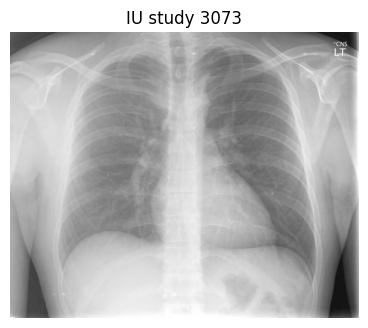

Proposed 3 questions in 7.2s

  [closed   ] Is there evidence of a pneumothorax on this chest radiograph?
  [open     ] What is the appearance of the lung fields in the lower zones?
  [technique] Is this image a frontal projection of the chest?


In [30]:
QUESTION_SYSTEM = (
    "You write evaluation questions about chest radiographs for a research dataset. "
    "You return JSON only, with no commentary."
)

QUESTION_TEMPLATE = """You are shown a frontal chest radiograph and its radiologist report.

REPORT FINDINGS: {findings}
REPORT IMPRESSION: {impression}

Write exactly {n} questions that a reader could answer by looking at this image, and \
that this report is able to confirm or refute. Use this mix:
- at least one closed-ended question (answerable yes/no)
- at least one open-ended question about a specific structure
- at least one question about overall image quality or projection

Do not ask about patient history, prior studies, or anything not visible.
Do not include the answers.

Return a JSON array of objects with keys "question" and "type", where "type" is one of \
"closed", "open", "technique". Return the array and nothing else."""

QUESTIONS_PER_STUDY = 3


def propose_questions(pil_image, findings, impression, n=QUESTIONS_PER_STUDY):
    """Return a list of {'question','type'} dicts, or [] if parsing fails."""
    instruction = QUESTION_TEMPLATE.format(
        findings=str(findings).strip(),
        impression=str(impression).strip(),
        n=n,
    )
    raw = generate_plain(pil_image, instruction, system=QUESTION_SYSTEM)
    parsed = extract_json(raw)
    if not isinstance(parsed, list):
        return []
    questions = []
    for item in parsed:
        if not isinstance(item, dict):
            continue
        text = str(item.get("question", "")).strip()
        kind = str(item.get("type", "open")).strip().lower()
        if len(text) < 8:
            continue
        if kind not in {"closed", "open", "technique"}:
            kind = "open"
        questions.append({"question": text, "type": kind})
    return questions[:n]


# Try it on one study before committing to a full run.
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
demo = frontal.sample(n=1, random_state=SEED).iloc[0]
demo_image = Image.open(demo["image_path"]).convert("RGB")

plt.figure(figsize=(4.5, 4.5))
plt.imshow(demo_image)
plt.axis("off")
plt.title(f"IU study {demo[P_UID]}")
plt.show()

started = time.time()
demo_questions = propose_questions(demo_image, demo[R_FINDINGS], demo[R_IMPRESSION])
print(f"Proposed {len(demo_questions)} questions in {time.time() - started:.1f}s\n")
for item in demo_questions:
    print(f"  [{item['type']:<9}] {item['question']}")

---
## 8. Stage 2 — answer from the image alone, with reasoning

The report is **withheld** here. The model gets the image and the question, thinking
enabled, and we keep both halves of its output.

This is where the dataset earns its keep. Whatever the model says now is a real attempt
at visual reasoning, and stage 3 can measure how often that attempt is wrong.

In [31]:
ANSWER_SYSTEM = (
    "You are a radiology research assistant. Answer only from what is visible in "
    "the image. If a finding cannot be assessed, say so explicitly rather than "
    "guessing. Do not refer to clinical history or prior studies."
)

ANSWER_TEMPLATE = """{question}

Answer in two to four sentences. Describe only what the image supports."""


def answer_question(pil_image, question):
    """Return (reasoning, answer) for one question, image-only."""
    reasoning, answer = generate_with_reasoning(
        pil_image,
        ANSWER_TEMPLATE.format(question=question),
        system=ANSWER_SYSTEM,
    )
    return reasoning.strip(), answer.strip()


# Demonstrate on the first proposed question, then check that reasoning capture
# actually worked. This costs one generation and saves discovering at assembly
# time that all N samples are unusable.
if not demo_questions:
    print("Stage 1 returned no questions; re-run it before continuing.")
else:
    started = time.time()
    demo_reasoning, demo_answer = answer_question(
        demo_image, demo_questions[0]["question"]
    )
    print(f"Answered in {time.time() - started:.1f}s\n")
    print("QUESTION:", demo_questions[0]["question"])
    print("\n--- analysis channel (reasoning) ---")
    print(demo_reasoning or "(EMPTY)")
    print("\n--- final channel (answer) ---")
    print(demo_answer or "(EMPTY - generation was truncated)")

    print("\n" + "=" * 70)
    if demo_reasoning and demo_answer:
        print("Reasoning capture OK. Both channels populated.")
    elif not demo_answer:
        print("WARNING: empty answer. The generation hit max_new_tokens before")
        print("finishing. Raise max_new_tokens in generate_with_reasoning.")
    else:
        print("WARNING: no reasoning captured. Every sample will be dropped later")
        print("if REQUIRE_REASONING stays True. Likely causes:")
        print("  - the chat template ignores enable_thinking, so the model never")
        print("    entered thinking mode. Inspect the raw output:")
        print("        raw = _generate(build_chat(demo_image, 'Describe this image.'),")
        print("                        512, enable_thinking=True)")
        print("        print(repr(raw[:2000]))")
        print("  - reasoning arrives in a shape split_reasoning does not know.")
        print("    Add it to the self-test cases in the helpers cell.")
        print("  If the model simply does not think here, set REQUIRE_REASONING")
        print("  = False in Section 11 and accept a final-channel-only dataset.")
    print("=" * 70)

Answered in 47.0s

QUESTION: Is there evidence of a pneumothorax on this chest radiograph?

--- analysis channel (reasoning) ---
The user wants to know if there is a pneumothorax based on the provided chest X-ray.

1.  **Analyze the image:**
    *   It's a frontal chest radiograph (likely PA view).
    *   Look at the lung apices and lateral chest walls.
    *   Look for a visceral pleural line.
    *   Look for absence of lung markings in a peripheral area.
    *   **Right lung:** Lung markings extend all the way to the periphery. The costophrenic angle is sharp. No visible pleural line.
    *   **Left lung:** Lung markings extend to the periphery. The costophrenic angle is sharp. No visible pleural line.
    *   **Mediastinum:** The trachea is midline. The heart borders are normal.
    *   **Bones:** Clavicles, ribs appear intact.
    *   **Soft tissues:** Normal.

2.  **Evaluate for pneumothorax:**
    *   A pneumothorax typically presents as a radiolucent area without lung markings

---
## 9. Stage 3 — grounding check

The radiologist report now acts as referee. We reuse the keyword-and-negation label
proxy from the Section 4 notebook so the two sessions report comparable numbers.

A sample is **contradicted** when the answer asserts a label that the report negates, or
denies a label the report asserts. Contradicted samples are dropped. Samples that assert
nothing checkable are kept but marked `unverified` — they are not evidence of quality,
merely absence of evidence of failure.

This filter is a proxy, not adjudication. It catches direct contradictions on nine common
labels and nothing else. Treat the pass rate as a floor on the error rate, never as a
quality guarantee.

In [21]:
FINDING_TERMS = {
    # "heart is enlarged" is included deliberately: it is the phrasing a
    # general-purpose model reaches for, and omitting it silently downgrades
    # real agreements to "unverified".
    "cardiomegaly": ["cardiomegaly", "enlarged heart", "enlarged cardiac",
                     "cardiac enlargement", "heart is enlarged",
                     "heart size is enlarged", "cardiac silhouette is enlarged"],
    "pleural_effusion": ["pleural effusion", "effusion"],
    "consolidation": ["consolidation", "airspace opacity", "airspace disease"],
    "pneumothorax": ["pneumothorax"],
    "edema": ["pulmonary edema", "edema", "vascular congestion"],
    "atelectasis": ["atelectasis", "atelectatic"],
    "nodule_or_mass": ["nodule", "mass", "lesion"],
    "fracture": ["fracture"],
    "device_or_line": ["catheter", "picc", "tube", "pacemaker",
                       "sternotomy", "wires"],
}
NEGATION_CUES = ("no ", "without", "absence of", "negative for", "free of",
                 "not seen", "resolved", "unremarkable")


def label_state(text, terms, window=60):
    """Return 'positive', 'negative', or 'absent' for one label in one text.

    Unlike the Section 4 helper this distinguishes an explicit denial from
    silence, which is what lets us detect a contradiction in either direction.
    """
    normalized = " " + str(text).lower().replace("\n", " ") + " "
    seen = False
    for term in terms:
        for match in re.finditer(re.escape(term), normalized):
            seen = True
            prefix = normalized[max(0, match.start() - window):match.start()]
            clause = re.split(r"[.;:\n]", prefix)[-1]
            if not any(cue in clause for cue in NEGATION_CUES):
                return "positive"
    return "negative" if seen else "absent"


def check_grounding(answer, reference):
    """Compare an answer against the radiologist report.

    Returns a dict with the verdict and the labels that drove it.
    """
    contradictions, agreements = [], []
    for label, terms in FINDING_TERMS.items():
        answer_state = label_state(answer, terms)
        reference_state = label_state(reference, terms)
        if answer_state == "absent" or reference_state == "absent":
            continue
        if answer_state == reference_state:
            agreements.append(label)
        else:
            contradictions.append(
                f"{label}: answer={answer_state}, report={reference_state}"
            )
    if contradictions:
        verdict = "contradicted"
    elif agreements:
        verdict = "supported"
    else:
        verdict = "unverified"
    return {
        "verdict": verdict,
        "contradictions": contradictions,
        "agreements": agreements,
    }


def reference_text(row):
    findings = str(row[R_FINDINGS]).strip() if pd.notna(row[R_FINDINGS]) else ""
    impression = str(row[R_IMPRESSION]).strip() if pd.notna(row[R_IMPRESSION]) else ""
    return f"FINDINGS: {findings}\n\nIMPRESSION: {impression}".strip()


# Sanity-check the checker itself on hand-written strings. If these assertions
# fail, the filter is broken and every downstream number is meaningless.
_ref = "FINDINGS: No pleural effusion. Mild cardiomegaly is present."
assert check_grounding("There is a large pleural effusion.", _ref)["verdict"] == "contradicted"
assert check_grounding("The heart is enlarged.", _ref)["verdict"] == "supported"
assert check_grounding("The image is adequately penetrated.", _ref)["verdict"] == "unverified"
print("Grounding checker passed its self-test.")

if demo_questions:
    demo_check = check_grounding(demo_answer, reference_text(demo))
    print("\nDemo verdict:", demo_check["verdict"])
    if demo_check["contradictions"]:
        print("Contradictions:", demo_check["contradictions"])

Grounding checker passed its self-test.

Demo verdict: contradicted
Contradictions: ['pneumothorax: answer=positive, report=negative']


---
## 10. Run the full pipeline

`N_STUDIES` controls dataset size. Cost is roughly
`N_STUDIES × (1 question call + QUESTIONS_PER_STUDY answer calls)`.

Start small — 20 studies is enough to inspect the output and see the failure modes.
A useful LoRA run wants a few thousand samples, which is an overnight job on a T4.

Every sample is kept in `raw_samples` regardless of verdict. Filtering happens at write
time, so you can inspect exactly what was thrown away and why.

In [32]:
N_STUDIES = 20
N_STUDIES = min(N_STUDIES, len(frontal))

study_sample = frontal.sample(n=N_STUDIES, random_state=SEED).reset_index(drop=True)

raw_samples = []
skipped = {"no_questions": 0, "empty_answer": 0}
run_started = time.time()

for position, row in study_sample.iterrows():
    pil_image = Image.open(row["image_path"]).convert("RGB")
    reference = reference_text(row)

    questions = propose_questions(pil_image, row[R_FINDINGS], row[R_IMPRESSION])
    if not questions:
        skipped["no_questions"] += 1
        print(f"[{position + 1}/{N_STUDIES}] uid={row[P_UID]} "
              f"- no parseable questions, skipping")
        continue

    verdicts = []
    for item in questions:
        reasoning, answer = answer_question(pil_image, item["question"])
        if not answer:
            # Truncated generation. Keeping it would teach the student model to
            # emit an empty final channel.
            skipped["empty_answer"] += 1
            continue
        check = check_grounding(answer, reference)
        verdicts.append(check["verdict"])
        raw_samples.append({
            "uid": int(row[P_UID]),
            "image_path": row["image_path"],
            "question": item["question"],
            "question_type": item["type"],
            "reasoning": reasoning,
            "answer": answer,
            "verdict": check["verdict"],
            "contradictions": check["contradictions"],
            "agreements": check["agreements"],
            "has_reasoning": bool(reasoning),
            "reference": reference,
        })

    summary = ", ".join(f"{v}={verdicts.count(v)}"
                        for v in ("supported", "unverified", "contradicted")
                        if verdicts.count(v))
    print(f"[{position + 1}/{N_STUDIES}] uid={row[P_UID]} "
          f"-> {len(verdicts)} samples ({summary or 'none'})")

elapsed = time.time() - run_started
print(f"\nGenerated {len(raw_samples)} raw samples from {N_STUDIES} studies "
      f"in {elapsed / 60:.1f} min")
print(f"Skipped: {skipped}")

[1/20] uid=3073 -> 3 samples (supported=2, unverified=1)
[2/20] uid=1125 -> 3 samples (supported=1, unverified=1, contradicted=1)
[3/20] uid=728 -> 3 samples (supported=2, unverified=1)
[4/20] uid=3095 -> 3 samples (supported=1, unverified=2)
[5/20] uid=3110 -> 3 samples (unverified=3)
[6/20] uid=3382 -> 3 samples (supported=1, unverified=2)
[7/20] uid=1223 -> 3 samples (unverified=3)
[8/20] uid=1079 -> 3 samples (unverified=1, contradicted=2)
[9/20] uid=126 -> 3 samples (unverified=2, contradicted=1)
[10/20] uid=242 -> 3 samples (supported=2, unverified=1)
[11/20] uid=1519 -> 3 samples (supported=1, unverified=1, contradicted=1)
[12/20] uid=870 -> 3 samples (unverified=3)
[13/20] uid=3096 -> 3 samples (supported=2, unverified=1)
[14/20] uid=557 -> 3 samples (supported=1, unverified=2)
[15/20] uid=2181 -> 3 samples (supported=2, contradicted=1)
[16/20] uid=20 -> 3 samples (supported=1, unverified=2)
[17/20] uid=931 -> 3 samples (unverified=3)
[18/20] uid=3606 -> 3 samples (unverified=3

In [33]:
samples_df = pd.DataFrame(raw_samples)
if samples_df.empty:
    raise RuntimeError("No samples generated. Inspect the stage 1 and 2 demos above.")

print("Verdict distribution:")
print(samples_df["verdict"].value_counts().to_string())
print("\nQuestion type distribution:")
print(samples_df["question_type"].value_counts().to_string())
print(f"\nSamples carrying a reasoning trace: "
      f"{samples_df['has_reasoning'].sum()}/{len(samples_df)}")

contradicted = samples_df[samples_df["verdict"] == "contradicted"]
print(f"\nContradiction rate: {len(contradicted) / len(samples_df):.1%}")
if not contradicted.empty:
    print("\nA contradicted sample, for inspection:")
    worst = contradicted.iloc[0]
    print("  Q:", worst["question"])
    print("  A:", worst["answer"][:300])
    print("  Why:", worst["contradictions"])

Verdict distribution:
verdict
unverified      36
supported       18
contradicted     6

Question type distribution:
question_type
closed       20
open         20
technique    20

Samples carrying a reasoning trace: 48/60

Contradiction rate: 10.0%

A contradicted sample, for inspection:
  Q: What specific findings are noted in the lung fields regarding interstitial markings and airspace opacities?
  A: The user wants me to describe the lung fields, specifically looking for interstitial markings and airspace opacities.

1.  **Analyze the image:**
    *   **Lung Fields:** I need to look at the lung parenchyma.
    *   **Right Lung:** The right lung field shows some increased opacity in the lower zon
  Why: ['consolidation: answer=positive, report=negative']


---
## 11. Assemble and validate the Harmony records

Only `supported` and `unverified` samples are written. `KEEP_UNVERIFIED = False` gives a
smaller, more defensible dataset; leaving it `True` gives more data with weaker
guarantees. That trade-off is worth an explicit decision rather than a default.

Where `openai-harmony` is importable we parse a rendered sample back and confirm the
channels survive the round trip. If the library is unavailable the notebook falls back to
a structural check on the token string, and says so.

In [34]:
KEEP_UNVERIFIED = True
MIN_ANSWER_CHARS = 40
REQUIRE_REASONING = True


def build_record(sample):
    messages = build_harmony_messages(
        question=sample["question"],
        reasoning=sample["reasoning"],
        answer=sample["answer"],
    )
    return {
        "uid": sample["uid"],
        "image": sample["image_path"],
        "messages": messages,
        "harmony_text": render_harmony(messages),
        "meta": {
            "question_type": sample["question_type"],
            "verdict": sample["verdict"],
            "agreements": sample["agreements"],
            "source_model": MODEL_ID,
            "dataset": DATASET_SLUG,
        },
    }


allowed = {"supported"} | ({"unverified"} if KEEP_UNVERIFIED else set())
kept, drop_reasons = [], []

for sample in raw_samples:
    if sample["verdict"] not in allowed:
        drop_reasons.append(f"verdict={sample['verdict']}")
        continue
    if len(sample["answer"]) < MIN_ANSWER_CHARS:
        drop_reasons.append("answer_too_short")
        continue
    if REQUIRE_REASONING and not sample["reasoning"]:
        drop_reasons.append("no_reasoning")
        continue
    kept.append(build_record(sample))

print(f"Kept {len(kept)} of {len(raw_samples)} samples")
if drop_reasons:
    print("\nDropped:")
    print(pd.Series(drop_reasons).value_counts().to_string())

if not kept:
    # A bare "everything was filtered" raise is useless - it names three knobs
    # without saying which one fired. Work out the actual cause and say so.
    counts = pd.Series(drop_reasons).value_counts()
    dominant = counts.index[0]
    n_reasoning = sum(1 for s in raw_samples if s["reasoning"])
    n_short = sum(1 for s in raw_samples if len(s["answer"]) < MIN_ANSWER_CHARS)

    print("\n" + "=" * 70)
    print("EVERY SAMPLE WAS FILTERED OUT")
    print("=" * 70)
    print(f"Dominant reason: {dominant}")
    print(f"Samples carrying reasoning: {n_reasoning}/{len(raw_samples)}")
    print(f"Answers under {MIN_ANSWER_CHARS} chars: {n_short}/{len(raw_samples)}")

    if dominant == "no_reasoning":
        print("\nThe model produced no reasoning trace for any sample.")
        print("Check the raw decoder output before changing any filter:")
        print("    raw = _generate(build_chat(demo_image, 'Describe this image.'),")
        print("                    512, enable_thinking=True)")
        print("    print(repr(raw[:2000]))")
        print("  - If <think> appears in it, split_reasoning is missing a shape;")
        print("    add it to the self-test in the helpers cell.")
        print("  - If it does not, this build ignores enable_thinking. Set")
        print("    REQUIRE_REASONING = False and re-run this cell for a")
        print("    final-channel-only dataset, which still trains.")
    elif dominant == "answer_too_short":
        print(f"\nEvery answer was under {MIN_ANSWER_CHARS} characters.")
        print("Either the model is answering tersely - lower MIN_ANSWER_CHARS -")
        print("or generations are being truncated; raise max_new_tokens.")
    else:
        print("\nEvery sample contradicted its report. Before loosening anything,")
        print("read a few: a contradiction rate of 100% usually means the")
        print("grounding proxy is misfiring, not that the model is always wrong.")
        for sample in raw_samples[:2]:
            print(f"\n  Q: {sample['question']}")
            print(f"  A: {sample['answer'][:200]}")
            print(f"  Why: {sample['contradictions']}")
    print("=" * 70)
    raise RuntimeError(f"No samples survived filtering (dominant: {dominant}).")

print("\n--- one rendered record ---")
print(kept[0]["harmony_text"][:1200])

Kept 46 of 60 samples

Dropped:
no_reasoning            8
verdict=contradicted    6

--- one rendered record ---
<|start|>system<|message|>You are a radiology research assistant.
Knowledge cutoff: 2024-06

Reasoning: medium

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>developer<|message|># Instructions

Answer questions about the chest radiograph shown. Describe only findings that are visible in the image. State uncertainty rather than asserting a finding you cannot see. Do not invent clinical history, prior comparisons, or measurements.<|end|><|start|>user<|message|><image>
Is there evidence of a pneumothorax on this chest radiograph?<|end|><|start|>assistant<|channel|>analysis<|message|>The user wants to know if there is a pneumothorax based on the provided chest X-ray.

1.  **Analyze the image:**
    *   It's a frontal chest radiograph (likely PA view).
    *   Look at the lung apices and lateral chest walls.
    *   Look

In [ ]:
def structural_check(text):
    """Verify the token string is well-formed without needing the library."""
    problems = []
    if not text.startswith(H_START + "system"):
        problems.append("does not start with a system message")
    if not text.endswith(H_RETURN):
        problems.append("does not end with <|return|>")
    if H_CHANNEL + "analysis" not in text:
        problems.append("no analysis channel")
    if H_CHANNEL + "final" not in text:
        problems.append("no final channel")
    # Every <|start|> needs exactly one terminator.
    starts = text.count(H_START)
    terminators = text.count(H_END) + text.count(H_RETURN)
    if starts != terminators:
        problems.append(f"{starts} starts vs {terminators} terminators")
    return problems


structural_problems = 0
for record in kept:
    if structural_check(record["harmony_text"]):
        structural_problems += 1
print(f"Structural check: {len(kept) - structural_problems}/{len(kept)} records valid")

try:
    from openai_harmony import load_harmony_encoding, HarmonyEncodingName

    encoding = load_harmony_encoding(HarmonyEncodingName.HARMONY_GPT_OSS)
    tokens = encoding.encode(kept[0]["harmony_text"], allowed_special="all")
    print(f"\nopenai-harmony tokenized the first record into {len(tokens)} tokens.")

    lengths = [
        len(encoding.encode(record["harmony_text"], allowed_special="all"))
        for record in kept
    ]
    print(f"Token length: min={min(lengths)}, median={int(pd.Series(lengths).median())}, "
          f"max={max(lengths)}")
    print("Set the training max_seq_len above the max, or long samples get truncated "
          "mid-answer and teach the model to stop early.")
except ImportError:
    print("\nopenai-harmony not installed; relying on the structural check above.")
except Exception as exc:
    print(f"\nopenai-harmony raised {type(exc).__name__}: {exc}")
    print("The structural check above still applies.")

---
## 12. Split and write JSONL

The split is **by study `uid`, not by sample**. Three questions about the same
radiograph share an image; splitting at sample level puts the same image on both sides
and inflates validation scores. This is the single easiest way to fool yourself with a
synthetic dataset.

In [35]:
import random

VAL_FRACTION = 0.1
OUTPUT_DIR = Path("/content/harmony_qa_dataset")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

uids = sorted({record["uid"] for record in kept})
rng = random.Random(SEED)
rng.shuffle(uids)

n_val = max(1, int(len(uids) * VAL_FRACTION)) if len(uids) > 1 else 0
val_uids = set(uids[:n_val])
train_uids = set(uids[n_val:])

train_records = [r for r in kept if r["uid"] in train_uids]
val_records = [r for r in kept if r["uid"] in val_uids]

assert not (train_uids & val_uids), "uid leaked across the split"
assert len(train_records) + len(val_records) == len(kept)


def write_jsonl(records, path):
    with open(path, "w", encoding="utf-8") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False) + "\n")
    return path


train_path = write_jsonl(train_records, OUTPUT_DIR / "train.jsonl")
val_path = write_jsonl(val_records, OUTPUT_DIR / "val.jsonl")

print(f"train: {len(train_records)} samples from {len(train_uids)} studies "
      f"-> {train_path}")
print(f"val:   {len(val_records)} samples from {len(val_uids)} studies "
      f"-> {val_path}")

manifest = {
    "source_model": MODEL_ID,
    "source_dataset": DATASET_SLUG,
    "format": "harmony",
    "image_sentinel": IMAGE_SENTINEL,
    "studies_processed": int(N_STUDIES),
    "questions_per_study": QUESTIONS_PER_STUDY,
    "raw_samples": len(raw_samples),
    "kept_samples": len(kept),
    "keep_unverified": KEEP_UNVERIFIED,
    "require_reasoning": REQUIRE_REASONING,
    "seed": SEED,
}
with open(OUTPUT_DIR / "manifest.json", "w", encoding="utf-8") as handle:
    json.dump(manifest, handle, indent=2)
print(f"\nmanifest -> {OUTPUT_DIR / 'manifest.json'}")
print(json.dumps(manifest, indent=2))

train: 42 samples from 18 studies -> /content/harmony_qa_dataset/train.jsonl
val:   4 samples from 2 studies -> /content/harmony_qa_dataset/val.jsonl

manifest -> /content/harmony_qa_dataset/manifest.json
{
  "source_model": "Qwen/Qwen3.5-4B",
  "source_dataset": "raddar/chest-xrays-indiana-university",
  "format": "harmony",
  "image_sentinel": "<image>",
  "studies_processed": 20,
  "questions_per_study": 3,
  "raw_samples": 60,
  "kept_samples": 46,
  "keep_unverified": true,
  "require_reasoning": true,
  "seed": 42
}


In [36]:
# Read the file back and confirm it survived serialisation. Trusting the
# in-memory objects here would miss exactly the encoding bugs that matter.
with open(train_path, encoding="utf-8") as handle:
    reloaded = [json.loads(line) for line in handle]

assert len(reloaded) == len(train_records), "line count changed on round trip"
assert reloaded[0]["harmony_text"] == train_records[0]["harmony_text"], \
    "harmony_text changed on round trip"
assert Path(reloaded[0]["image"]).exists(), "image path in the JSONL does not resolve"
print(f"Round trip verified on {len(reloaded)} records.")

print("\n--- first training record, fields ---")
first = reloaded[0]
print("uid:  ", first["uid"])
print("image:", first["image"])
print("meta: ", json.dumps(first["meta"]))
print("\nmessages:")
for message in first["messages"]:
    channel = f" [{message['channel']}]" if message.get("channel") else ""
    preview = message["content"].replace("\n", " ")[:110]
    print(f"  {message['role']}{channel}: {preview}")

Round trip verified on 42 records.

--- first training record, fields ---
uid:   3073
image: /content/iu_xray/images/images_normalized/3073_IM-1434-1001.dcm.png
meta:  {"question_type": "closed", "verdict": "supported", "agreements": ["pneumothorax"], "source_model": "Qwen/Qwen3.5-4B", "dataset": "raddar/chest-xrays-indiana-university"}

messages:
  system: You are a radiology research assistant. Knowledge cutoff: 2024-06  Reasoning: medium  # Valid channels: analys
  developer: # Instructions  Answer questions about the chest radiograph shown. Describe only findings that are visible in 
  user: <image> Is there evidence of a pneumothorax on this chest radiograph?
  assistant [analysis]: The user wants to know if there is a pneumothorax based on the provided chest X-ray.  1.  **Analyze the image:
  assistant [final]: No, there is no evidence of a pneumothorax on this chest radiograph. Lung markings are visible extending to th


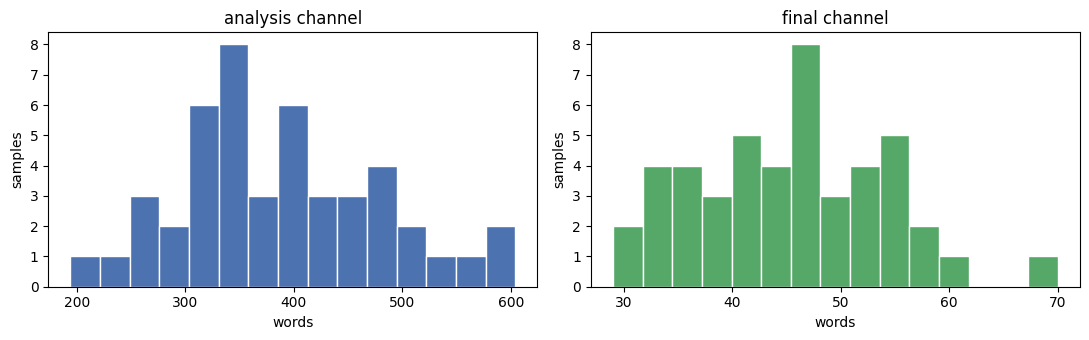

analysis: median 372 words
final:    median 46 words


In [37]:
# Answer-length distribution per channel. A dataset where the analysis channel
# is systematically longer than the final channel trains a model that thinks at
# length and answers tersely - which may or may not be what you want, but should
# be a choice rather than an accident.
analysis_lengths, final_lengths = [], []
for record in kept:
    for message in record["messages"]:
        if message.get("channel") == "analysis":
            analysis_lengths.append(len(message["content"].split()))
        elif message.get("channel") == "final":
            final_lengths.append(len(message["content"].split()))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(analysis_lengths, bins=15, color="#4c72b0", edgecolor="white")
axes[0].set(title="analysis channel", xlabel="words", ylabel="samples")
axes[1].hist(final_lengths, bins=15, color="#55a868", edgecolor="white")
axes[1].set(title="final channel", xlabel="words", ylabel="samples")
plt.tight_layout()
plt.show()

print(f"analysis: median {int(pd.Series(analysis_lengths).median())} words")
print(f"final:    median {int(pd.Series(final_lengths).median())} words")

---
## 13. Download the dataset

Colab discards `/content` when the runtime recycles, so the JSONL files are packaged and
pushed to your browser before anything else happens. The archive holds `train.jsonl`,
`val.jsonl`, and `manifest.json`.

Images are **not** included — they stay in the IU dataset, and each record points at one
by path. That keeps the archive small (kilobytes rather than gigabytes), but it means the
`image` paths only resolve on a machine that also has the IU data extracted. Set
`REWRITE_IMAGE_PATHS_RELATIVE = True` to store `images/CXR123_IM-0001-1001.png` instead of
an absolute `/content/...` path, which is what you want if the training run happens
somewhere else.

In [38]:
REWRITE_IMAGE_PATHS_RELATIVE = True
ARCHIVE_PATH = Path("/content/harmony_qa_dataset.zip")


def relativize(records):
    """Point each record at images/<basename> instead of an absolute path.

    Absolute /content paths are meaningless on any machine but this runtime, so
    a dataset shipped with them silently fails to load elsewhere.
    """
    out = []
    for record in records:
        copy = dict(record)
        copy["image"] = f"images/{Path(record['image']).name}"
        out.append(copy)
    return out


if REWRITE_IMAGE_PATHS_RELATIVE:
    write_jsonl(relativize(train_records), OUTPUT_DIR / "train.jsonl")
    write_jsonl(relativize(val_records), OUTPUT_DIR / "val.jsonl")
    print("Image paths rewritten to images/<filename>.")
    print(f"Resolve them against your local copy of {DATASET_SLUG}.")

with zipfile.ZipFile(ARCHIVE_PATH, "w", zipfile.ZIP_DEFLATED) as archive:
    for name in ("train.jsonl", "val.jsonl", "manifest.json"):
        path = OUTPUT_DIR / name
        if path.exists():
            archive.write(path, arcname=name)
            print(f"  added {name} ({path.stat().st_size / 1024:.1f} KB)")

print(f"\nArchive: {ARCHIVE_PATH} "
      f"({ARCHIVE_PATH.stat().st_size / 1024:.1f} KB)")

try:
    from google.colab import files as colab_files
    colab_files.download(str(ARCHIVE_PATH))
    print("Download triggered. Check your browser's downloads.")
except ImportError:
    print(f"Not running in Colab - collect the archive from {ARCHIVE_PATH}")
except Exception as exc:
    print(f"Automatic download failed ({type(exc).__name__}: {exc}).")
    print(f"Download it manually from the Files pane: {ARCHIVE_PATH}")

Image paths rewritten to images/<filename>.
Resolve them against your local copy of raddar/chest-xrays-indiana-university.
  added train.jsonl (313.6 KB)
  added val.jsonl (24.8 KB)
  added manifest.json (0.3 KB)

Archive: /content/harmony_qa_dataset.zip (30.3 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered. Check your browser's downloads.


---
## 14. Consuming this dataset for LoRA fine-tuning

Training lives in the companion notebook. What that notebook needs from this one:

**Loading.** Each JSONL line is one conversation. `datasets.load_dataset("json",
data_files=...)` reads it directly.

**Channel masking.** The reason for keeping `analysis` and `final` as separate messages
is that you can choose what to compute loss over:

| Strategy | Loss over | Effect |
|---|---|---|
| Answer-only | `final` | Model learns the answer; reasoning is context only |
| Full | `analysis` + `final` | Model learns to reason aloud, then answer |
| Weighted | both, `analysis` down-weighted | Middle ground; needs a custom loss |

Build the label mask by locating the `<|channel|>final<|message|>` span in the tokenised
sequence and setting everything before it to `-100`.

**Images.** Split `content` on the `<image>` sentinel and splice in the processed image
tokens at that position. For a text-only student model, drop the sentinel and the
`image` field entirely.

**Suggested starting LoRA configuration**, given a dataset in the low thousands:

```python
LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05, bias="none",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    task_type="CAUSAL_LM",
)
```

Rank 16 is a reasonable default; below rank 8 the adapter often cannot fit the format,
and above 64 it starts memorising a dataset this size. Attention-only targets train
faster but usually underperform when the target format is unfamiliar to the base model —
and Harmony *is* unfamiliar to Qwen3.5, which is the interesting part.

**Before you train, be clear about what this data is.** It is one 4B general-purpose
model's opinion about chest radiographs, filtered by a nine-label keyword proxy. A
student trained on it learns to imitate Qwen3.5, including its errors — the contradiction
rate printed in Section 10 is a lower bound on how often. That is a legitimate
distillation experiment. It is not a route to a clinically useful model, and the Section 5
papers explain in detail why the distinction matters.

---
## 15. Discussion prompts

1. **The referee problem.** Stage 3 uses the radiologist report to judge answers. But the
   report was written with the patient's history and prior films available, and the model
   sees neither. How many "contradictions" are actually the model being appropriately
   cautious about something genuinely invisible on a single frontal view?

2. **Distillation ceiling.** Can a student fine-tuned on Qwen3.5's outputs exceed
   Qwen3.5? Under what conditions is that possible at all?

3. **Reasoning fidelity.** The `analysis` channel holds what the model emitted between
   `<think>` tags. Is that its actual computation, or a post-hoc narrative? Does the
   answer change if you strip the reasoning at training time?

4. **Filter strength.** Compare a run with `KEEP_UNVERIFIED = True` against one with
   `False`. Does the smaller, cleaner dataset train a better model — and how would you
   even measure that without a held-out human-labelled set?

5. **Connection to the papers.** Dorfner et al. found biomedically fine-tuned LLMs
   underperform general-purpose ones and hallucinate more. Does the way this dataset is
   built make that outcome more likely or less?

6. **Cheaper alternatives.** Every sample here costs four model calls. What would you
   lose by generating questions from the report text alone, without the image?